In [1]:
########################################################
# This Routine Plots the 2D and 3D light profile of the#
# brightest star in a field and saves the plots in the #
# same directory as the data                           #
########################################################

In [12]:
import math
import numpy as np
import os
import matplotlib.pyplot as plt
from astropy.stats import mad_std
from photutils.detection import DAOStarFinder
from astropy.io import fits
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def make_cutout(image, x, y, size=40):
    """Return a small cutout centered on (x, y)."""
    x, y = int(x), int(y)
    half = size // 2
    return image[max(0, y - half): y + half, max(0, x - half): x + half]

def browse_detections(image, sources, N=20, size=40, cmap='inferno'):
    """
    Show thumbnails of detections in groups of N.
    Type the source index to select your star, Enter for next page, or 'q' to quit.
    
    Returns:
        (x_centroid, y_centroid) of the selected star, or (None, None) if none selected.
    """
    sorted_indices = np.argsort(sources['flux'])[::-1]  # descending order
    total = len(sorted_indices)
    start = 0

    while start < total:
        end = min(start + N, total)
        subset = sorted_indices[start:end]

        ncols = 5
        nrows = math.ceil(len(subset) / ncols)
        fig, axs = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
        axs = axs.ravel()

        for i, sidx in enumerate(subset):
            src = sources[sidx]
            cut = make_cutout(image, src['xcentroid'], src['ycentroid'], size=size)
            axs[i].imshow(cut, origin='lower', cmap=cmap)
            axs[i].set_title(f"i={sidx}\nflux={src['flux']:.0f}")
            axs[i].axis('off')

        for j in range(i + 1, len(axs)):
            axs[j].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"Showing detections {start+1}–{end} of {total}.")
        cmd = input("Type the index of your star, Enter for next page, or 'q' to quit: ").strip().lower()

        if cmd == 'q':
            print("No star selected. Exiting.")
            return None, None
        elif cmd.isdigit():
            chosen_idx = int(cmd)
            if chosen_idx in subset:
                target_star = sources[chosen_idx]
                x_centroid = target_star['xcentroid']
                y_centroid = target_star['ycentroid']
                print(f"Selected star index {chosen_idx} at x={x_centroid:.2f}, y={y_centroid:.2f}")
                return x_centroid, y_centroid
            else:
                print(f"Index {chosen_idx} not in this page. Try again.")
        else:
            # Enter pressed, move to next page
            start += N

    print("Reached end of sources. No star selected.")
    return None, None


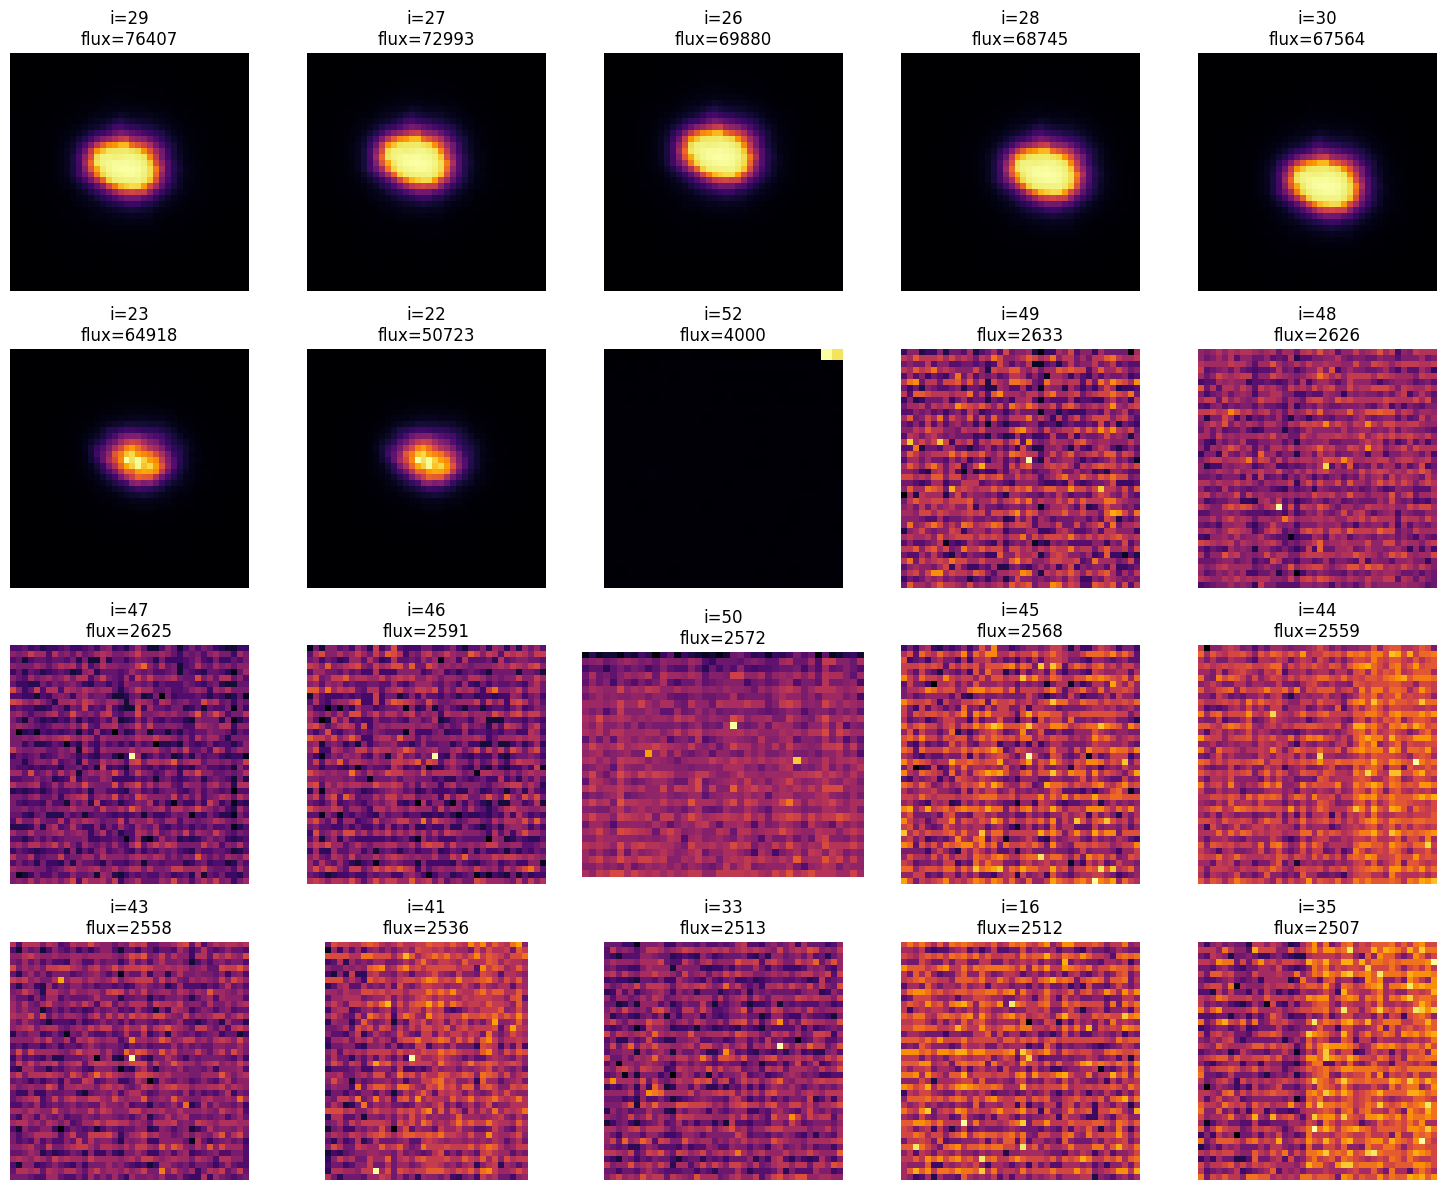

Showing detections 1–20 of 53.


Type the index of your star, Enter for next page, or 'q' to quit:  22


Selected star index 22 at x=681.84, y=623.17


(681.8367428008983, 623.1669256280137)

In [13]:
# Load the FITS file
filename = "C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B/i_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1.fit"
hdul = fits.open(filename)
image_data = hdul[0].data
hdul.close()

# Run DAOStarFinder as before
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=3.*bkg_sigma)
sources = daofind(image_data)
# Browse detections interactively in groups of 20
browse_detections(image_data, sources, N=20, size=40)


Average FWHM: 0.00 arcsec
Plot saved to C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B\i_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1_2D_light_profile.png


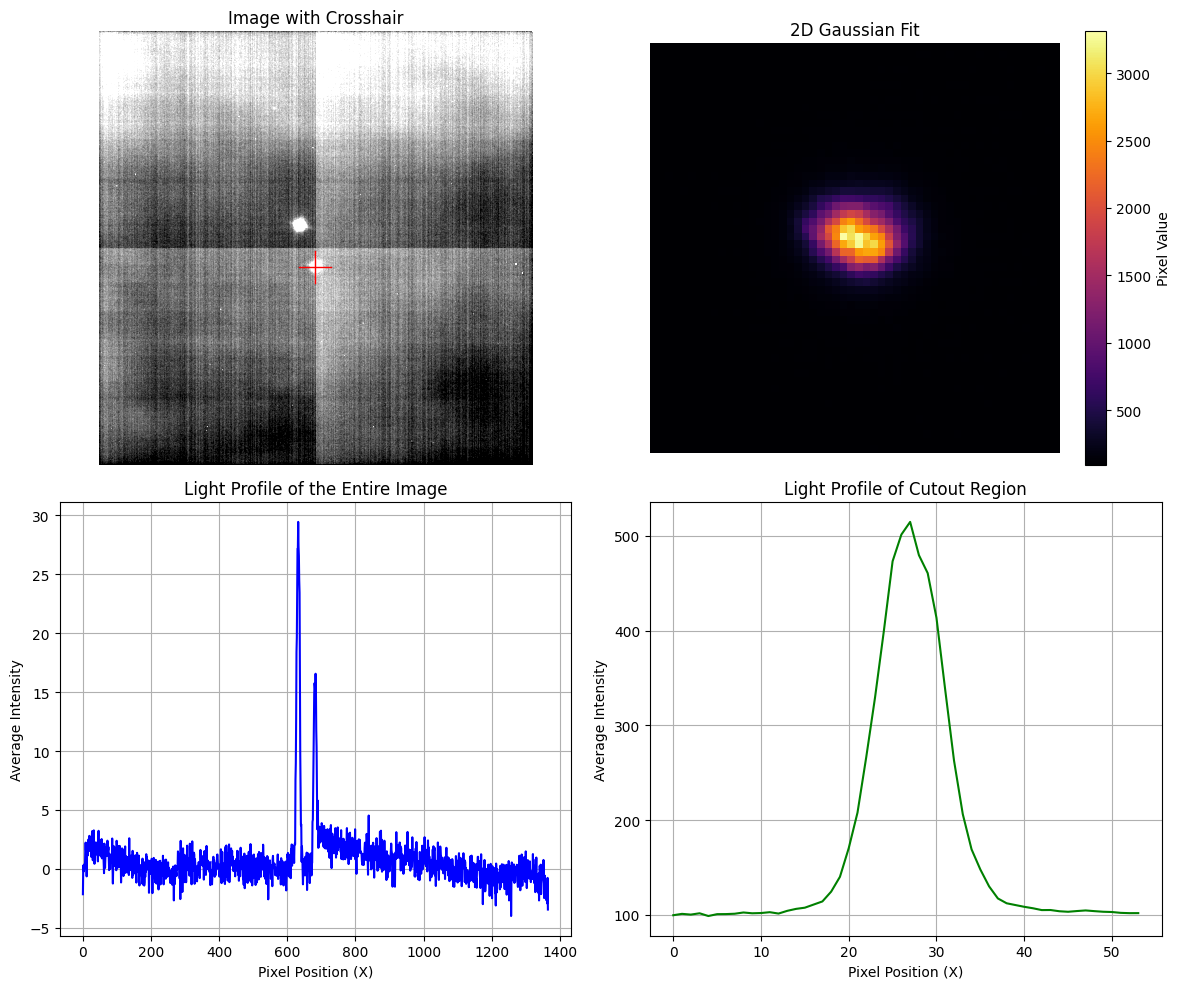

Plot saved to C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B\i_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1_3D_second_brightest.png


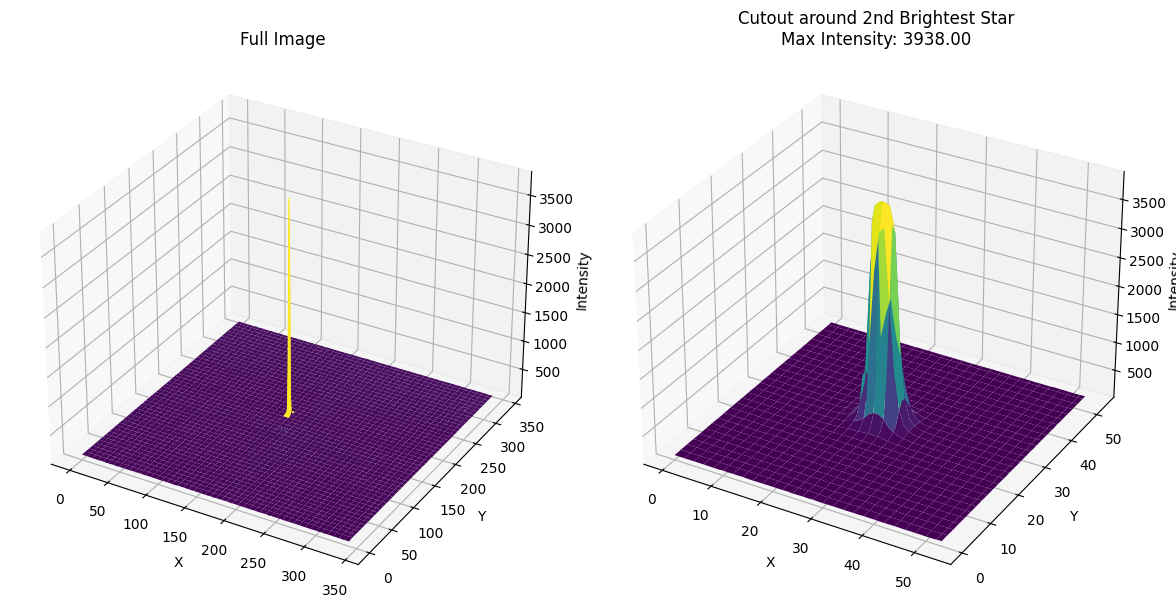

In [15]:
# manually pick the index of the region you are interested in after looking
chosen_idx = 22  
target_star = sources[chosen_idx]
x_centroid = target_star['xcentroid']
y_centroid = target_star['ycentroid']

# --- Cutout region around the selected star ---
Size_of_the_cutout_region = 30
size = Size_of_the_cutout_region

x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
cutout = image_data[y_min:y_max, x_min:x_max]

# --- Create coordinate grids for Gaussian fitting ---
y_grid, x_grid = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# --- Define initial 2D Gaussian ---
g_init = models.Gaussian2D(amplitude=cutout.max(),
                           x_mean=size//2, y_mean=size//2,
                           x_stddev=3, y_stddev=3)

# --- Fit Gaussian to the cutout ---
fitter = fitting.LevMarLSQFitter()
g_fit = fitter(g_init, x_grid, y_grid, cutout)

# --- Compute FWHM ---
fwhm_x = 2.355 * g_fit.x_stddev.value
fwhm_y = 2.355 * g_fit.y_stddev.value
fwhm_avg = (((fwhm_x + fwhm_y) / 2) * 0.051)  # convert pixels to arcsec if 0.051"/px
print(f"Average FWHM: {fwhm_avg:.2f} arcsec")

# --- Full image light profile ---
mean_full, median_full, std_full = sigma_clipped_stats(image_data, sigma=3.0)
data_sub_full = image_data - median_full
light_profile_full = np.mean(data_sub_full, axis=0)

# --- Cutout light profile ---
data_sub_cutout = image_data[y_min:y_max, x_min:x_max]
light_profile_cutout = np.mean(data_sub_cutout, axis=0)

# --- Plotting ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 1) Full image with crosshair
axs[0, 0].imshow(image_data, cmap='gray',
                 vmin=np.percentile(image_data, 10),
                 vmax=np.percentile(image_data, 90),
                 origin='lower')
axs[0, 0].set_title("Image with Crosshair")
axs[0, 0].axis('off')
crosshair_size = 50
axs[0, 0].plot([x_centroid - crosshair_size, x_centroid + crosshair_size],
               [y_centroid, y_centroid], 'r-', linewidth=1)
axs[0, 0].plot([x_centroid, x_centroid],
               [y_centroid - crosshair_size, y_centroid + crosshair_size],
               'r-', linewidth=1)

# 2) Cutout with Gaussian fit
im = axs[0, 1].imshow(cutout, cmap='inferno', origin='lower')
axs[0, 1].contour(g_fit(x_grid, y_grid), colors='white', linewidths=1)
axs[0, 1].set_title("2D Gaussian Fit")
axs[0, 1].axis('off')
fig.colorbar(im, ax=axs[0, 1], label="Pixel Value")

# 3) Full image light profile
axs[1, 0].plot(light_profile_full, 'b-')
axs[1, 0].set_xlabel('Pixel Position (X)')
axs[1, 0].set_ylabel('Average Intensity')
axs[1, 0].set_title('Light Profile of the Entire Image')
axs[1, 0].grid()

# 4) Cutout light profile
axs[1, 1].plot(light_profile_cutout, 'g-')
axs[1, 1].set_xlabel('Pixel Position (X)')
axs[1, 1].set_ylabel('Average Intensity')
axs[1, 1].set_title('Light Profile of Cutout Region')
axs[1, 1].grid()

plt.tight_layout()

# --- Save figure ---
base_filename = os.path.basename(filename)
name, ext = os.path.splitext(base_filename)
plot_filename = os.path.join(os.path.dirname(filename), f"{name}_2D_light_profile.png")
try:
    plt.savefig(plot_filename)
    print(f"Plot saved to {plot_filename}")
except Exception as e:
    print(f"Error saving plot: {e}")

# Show plot
plt.show()


# --- Detect stars ---
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)

if sources is not None and len(sources) > 0:
    # --- Pick second brightest safely ---
    sorted_indices = np.argsort(sources['flux'])[::-1]
    if len(sorted_indices) > 1:
        second_idx = sorted_indices[1]
    else:
        second_idx = sorted_indices[0]  # fallback if only one star
    star = sources[second_idx]
    x_centroid, y_centroid = star['xcentroid'], star['ycentroid']

    # --- Cutout around the star ---
    cutout_size = 60  # pixels
    x_min = max(int(x_centroid - cutout_size//1.1), 0)
    x_max = min(int(x_centroid + cutout_size//1.1), image_data.shape[1])
    y_min = max(int(y_centroid - cutout_size//1.1), 0)
    y_max = min(int(y_centroid + cutout_size//1.1), image_data.shape[0])
    cutout = image_data[y_min:y_max, x_min:x_max]

    # --- Downsample for 3D plotting if image is large ---
    def downsample(arr, factor=4):
        if factor <= 1:
            return arr
        return arr[::factor, ::factor]

    ds_factor_full = 4
    ds_factor_cutout = 2
    image_ds = downsample(image_data, ds_factor_full)
    cutout_ds = downsample(cutout, ds_factor_cutout)

    # Coordinate grids for 3D plots
    y1, x1 = np.mgrid[:image_ds.shape[0], :image_ds.shape[1]]
    y2, x2 = np.mgrid[:cutout_ds.shape[0], :cutout_ds.shape[1]]

    # --- Create 3D figure ---
    fig = plt.figure(figsize=(12, 6))

    # Full image
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(x1, y1, image_ds, cmap='viridis')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Intensity')
    ax1.set_title('Full Image')

    # Cutout
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(x2, y2, cutout_ds, cmap='viridis')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Intensity')
    ax2.set_title(f'Cutout around 2nd Brightest Star\nMax Intensity: {np.max(cutout):.2f}')

    plt.tight_layout()

    # --- Save figure ---
    base_filename = os.path.basename(filename)
    name, ext = os.path.splitext(base_filename)
    plot_filename = os.path.join(os.path.dirname(filename), f"{name}_3D_second_brightest.png")
    try:
        plt.savefig(plot_filename)
        print(f"Plot saved to {plot_filename}")
    except Exception as e:
        print(f"Error saving plot: {e}")

    plt.show()
else:
    print("No stars found in the image.")



In [ ]:
# Older Versions of this code

Average FWHM: 0.00 arcsec
Plot saved to C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B\i_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1_2D_light_profile.png


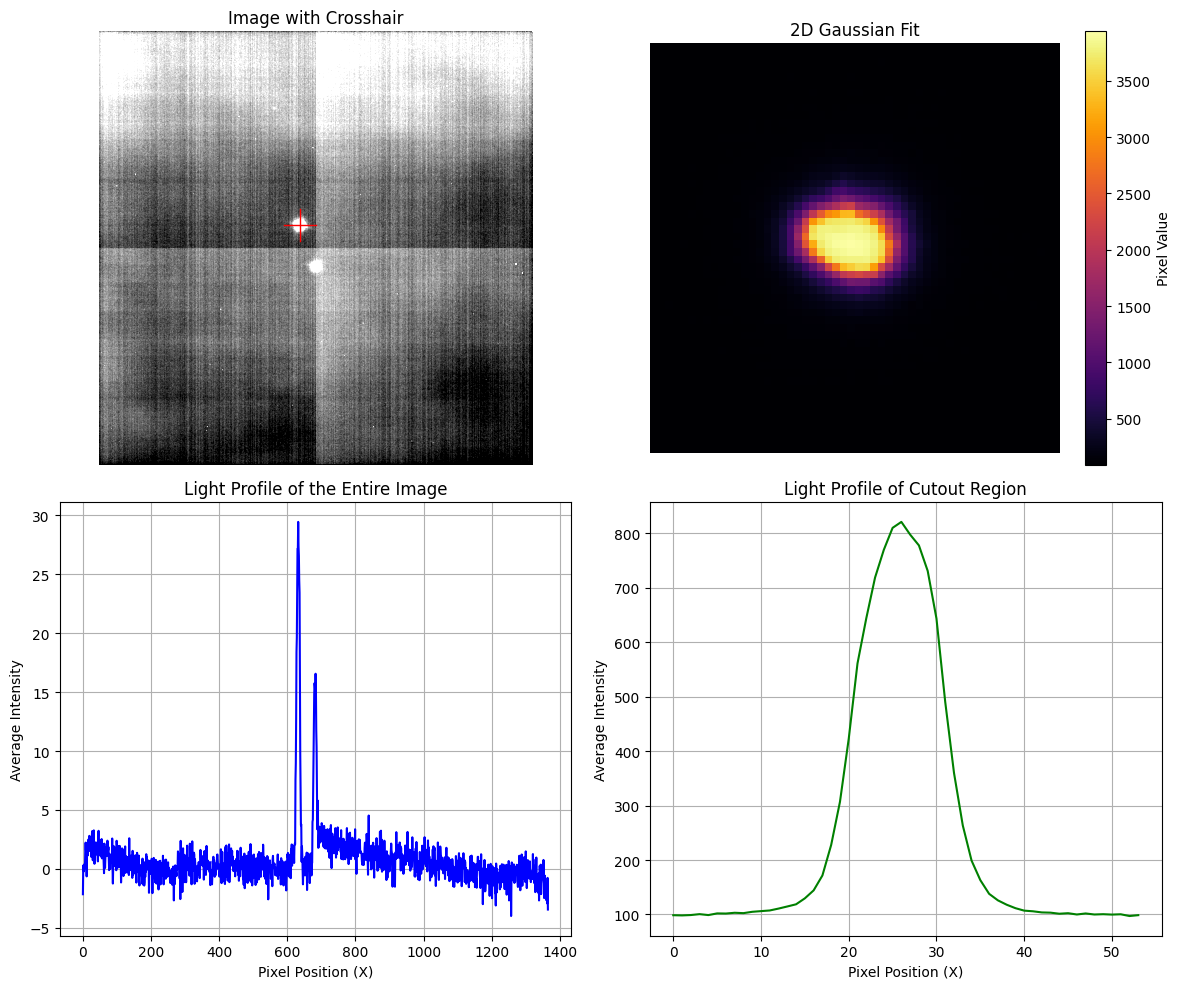

In [4]:
import astropy
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from convenience_functions import show_image 
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
from astropy.modeling import models, fitting
from astropy.stats import sigma_clipped_stats
from mpl_toolkits.mplot3d import Axes3D
import os 

# Load the FITS file
filename = "C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B/i_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1.fit"
hdul = fits.open(filename)
image_data = hdul[0].data
hdul.close()

# Star finding
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)

def show_image(image_data, cmap='gray', percl=90, fig=None, ax=None):
    """Displays an image with percentile contrast scaling using matplotlib.

    Args:
        image_data (numpy.ndarray): The image data to display.
        cmap (str, optional): The colormap to use. Defaults to 'gray'.
        percl (float, optional): The percentile for contrast scaling. Defaults to 90.
        fig (matplotlib.figure.Figure, optional): The figure object to plot on. Defaults to None.
        ax (matplotlib.axes._axes.Axes, optional): The axes object to plot on.  If None, a new one is created.
    """
    vmin, vmax = np.percentile(image_data, (100 - percl, percl))

    if ax is None and fig is None:
        fig, ax = plt.subplots(1) # Create figure and axes if neither are provided
    elif ax is None and fig is not None:
        ax = fig.add_subplot(111) # Add subplot to existing figure if only fig is provided
    elif fig is None and ax is not None:
        fig = ax.figure # Get the figure from the axes object.


    ax.imshow(image_data, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')  #Crucially uses ax.imshow
    ax.axis('off') # Turn off axis labels

    return fig, ax  # Return both figure and axes object


brightest_star = sources[np.argmax(sources['flux'])]
x_centroid, y_centroid = brightest_star['xcentroid'], brightest_star['ycentroid']

Size_of_the_cutout_region=30
size = Size_of_the_cutout_region

### Change 1.1 to change the size of the Cutout region###
x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
cutout = image_data[y_min:y_max, x_min:x_max]
# Create coordinate grids
y, x = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# Define a 2D Gaussian model
g_init = models.Gaussian2D(amplitude=cutout.max(),
                           x_mean=size//2, y_mean=size//2,
                           x_stddev=3, y_stddev=3)

# Fit the model to the cutout data
fitter = fitting.LevMarLSQFitter()
g_fit = fitter(g_init, x, y, cutout)

# Calculate FWHM using the Gaussian relation: FWHM = 2.355 * sigma
fwhm_x = 2.355 * g_fit.x_stddev.value
fwhm_y = 2.355 * g_fit.y_stddev.value
fwhm_avg = (((fwhm_x + fwhm_y) / 2)*0.051)
print(f"Average FWHM: {fwhm_avg:.2f} arcsec")

# --- Calculate Light Profiles ---
# Calculate background statistics
mean_full, median_full, std_full = sigma_clipped_stats(image_data, sigma=3.0)

# Subtract the median to remove the background
data_sub_full = image_data - median_full

# Calculate the light profile by averaging along the y-axis
light_profile_full = np.mean(data_sub_full, axis=0)


# --- Code for Cutout Profile (Second Code) ---
### Change 1.1 to change the size of the Cutout region###
size = Size_of_the_cutout_region
x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
data_sub_cutout = image_data[y_min:y_max, x_min:x_max]
light_profile_cutout = np.mean(data_sub_cutout, axis=0)


# --- Create the Figure and Subplots ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns, increased figsize
# --- Plot 1: Image with Crosshair ---
# Display the image with a crosshair on the first subplot
axs[0, 0].imshow(image_data, cmap='gray', vmin=np.percentile(image_data, 10), vmax=np.percentile(image_data, 90), origin='lower')  # Using imshow directly and calculating vmin/vmax
axs[0, 0].set_title("Image with Crosshair")
axs[0, 0].axis('off')  # Turn off axis labels


# Add crosshair
crosshair_size = 50  # Adjust for desired crosshair size

axs[0, 0].plot([x_centroid - crosshair_size, x_centroid + crosshair_size], [y_centroid, y_centroid], 'r-', linewidth=1)  # Horizontal line
axs[0, 0].plot([x_centroid, x_centroid], [y_centroid - crosshair_size, y_centroid + crosshair_size], 'r-', linewidth=1)  # Vertical line


# --- Plot 2: Cutout with Gaussian Fit ---
# Plot the cutout with the Gaussian fit on the second subplot
im = axs[0, 1].imshow(cutout, cmap='inferno', origin='lower')
axs[0, 1].contour(g_fit(x, y), colors='white', linewidths=1)
axs[0, 1].set_title("2D Gaussian Fit")
axs[0, 1].axis('off')
fig.colorbar(im, ax=axs[0, 1], label="Pixel Value") # add colorbar to the second subplot


# --- Plot 3: Full Image Light Profile ---
axs[1, 0].plot(light_profile_full, 'b-')
axs[1, 0].set_xlabel('Pixel Position (X)')
axs[1, 0].set_ylabel('Average Intensity')
axs[1, 0].set_title('Light Profile of the Entire Image')
axs[1, 0].grid()


# --- Plot 4: Cutout Light Profile ---
axs[1, 1].plot(light_profile_cutout, 'g-')  # Use a different color (green)
axs[1, 1].set_xlabel('Pixel Position (X)')
axs[1, 1].set_ylabel('Average Intensity')
axs[1, 1].set_title('Light Profile of Cutout Region')
axs[1, 1].grid()


# Adjust layout to prevent overlap
plt.tight_layout()

# Construct the filename for saving the plot
base_filename = os.path.basename(filename)
name, ext = os.path.splitext(base_filename)
plot_filename = os.path.join(os.path.dirname(filename), f"{name}_2D_light_profile.png")

# Save the figure
try:
    plt.savefig(plot_filename)
    print(f"Plot saved to {plot_filename}")
except Exception as e:
    print(f"Error saving plot: {e}")

# Show the combined plot
plt.show()

Plot saved to C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B\i_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1_3D_light_profile.png


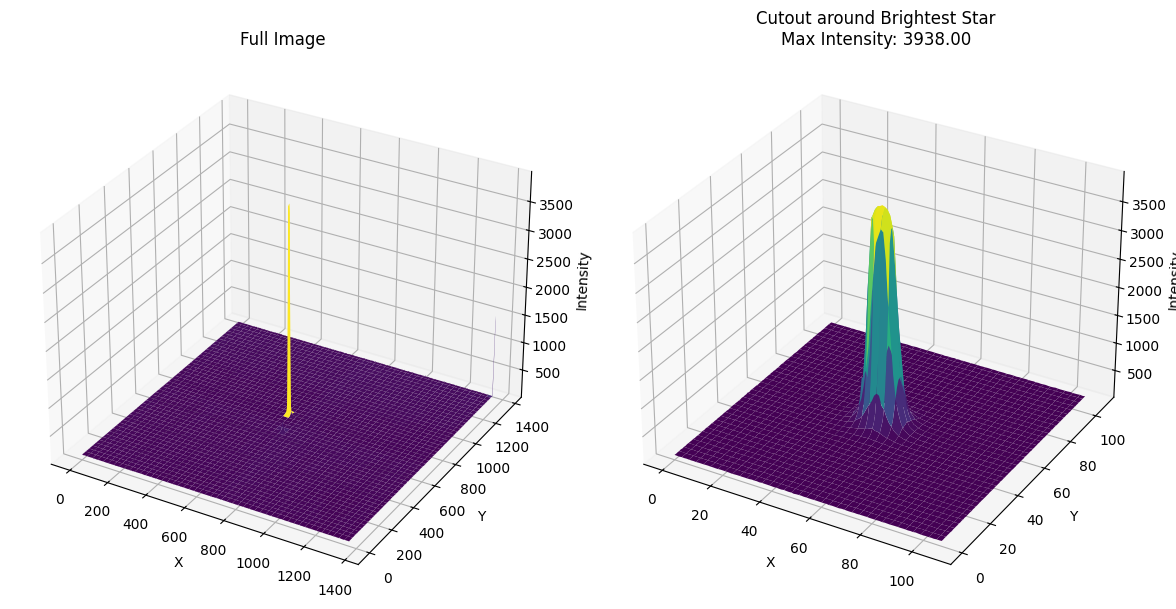

In [5]:
#x
#y
# The numbers show how the average brightness changes as you move across the cutout region,
# from one side to the other.
#light_profile_cutout




# --- Plot 1: Full Image ---
y1, x1 = np.mgrid[:image_data.shape[0], :image_data.shape[1]]

# --- Plot 2: Cutout around Brightest Star ---
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)
if sources is not None:
    brightest_star = sources[np.argmax(sources['flux'])]
    x_centroid, y_centroid = brightest_star['xcentroid'], brightest_star['ycentroid']
    size = 60
    x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
    y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
    cutout = image_data[y_min:y_max, x_min:x_max]
    y2, x2 = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    # --- Create the Figure with Subplots ---
    fig = plt.figure(figsize=(12, 6))  # Adjust size as needed

    # Plot 1: Full Image
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(x1, y1, image_data, cmap='viridis')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Intensity')
    ax1.set_title('Full Image')

    # Plot 2: Cutout
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(x2, y2, cutout, cmap='viridis')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Intensity')
    ax2.set_title(f'Cutout around Brightest Star\nMax Intensity: {np.max(cutout):.2f}')

    plt.tight_layout()

    # Construct the filename for saving the plot
    base_filename = os.path.basename(filename)
    name, ext = os.path.splitext(base_filename)
    plot_filename = os.path.join(os.path.dirname(filename), f"{name}_3D_light_profile.png")

    # Save the figure
    try:
        plt.savefig(plot_filename)
        print(f"Plot saved to {plot_filename}")
    except Exception as e:
        print(f"Error saving plot: {e}")

    plt.show()
else:
    print("No stars found in the image.")